# Grain Sentinel STL Validation and Tuning

Offline validation of STL decomposition plus rolling MAD thresholding. The target anomaly is a synthetic slow high-temperature rise, so the tuned detector uses positive residual threshold crossings.

In [1]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "scripts").exists():
    PROJECT_DIR = PROJECT_DIR.parent
sys.path.insert(0, str(PROJECT_DIR))

from scripts.stl_anomaly_detection import (
    ANALYSIS_END,
    ANALYSIS_START,
    ANOMALY_START,
    BEST_CONSECUTIVE_POINTS,
    BEST_THRESHOLD_MULTIPLIER,
    DETECTION_DIRECTION,
    EXTENDED_THRESHOLD_MULTIPLIERS,
    MIN_CONSECUTIVE_POINTS,
    PLOT_PATH,
    REQUESTED_THRESHOLD_MULTIPLIERS,
    RESAMPLE_RULE,
    ROLLING_WINDOW,
    STL_PERIOD,
    STL_TREND_WINDOW,
    TEMP_COL,
    TIMESTAMP_COL,
    TUNED_PLOT_PATH,
    TUNING_CONSECUTIVE_OPTIONS,
    TUNING_RESULTS_PATH,
    compute_metrics,
    detect_anomalies,
    inject_slow_rise,
    load_temperature_series,
    plot_detection,
    run_tuning_grid,
    select_best_parameters,
)

plt.rcParams["figure.figsize"] = (14, 4)

In [2]:
df, analysis_df, raw_temperature, median_frequency = load_temperature_series()
analysis_temperature, injected_mask, anomaly_end = inject_slow_rise(raw_temperature)

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Timestamp column: {TIMESTAMP_COL}")
print(f"Temperature column: {TEMP_COL}")
print(f"Analysis window: {ANALYSIS_START} to {ANALYSIS_END}")
print(f"Rows before resampling: {analysis_df.shape[0]}")
print(f"Median sampling interval: {median_frequency}")
print(f"Resampled frequency: {RESAMPLE_RULE}")
print(f"STL period: {STL_PERIOD}")
print(f"STL trend window: {STL_TREND_WINDOW}")
print(f"Rolling MAD window: {ROLLING_WINDOW}")
print(f"Injected anomaly points: {int(injected_mask.sum())}")
print(f"Synthetic anomaly window: {ANOMALY_START} to {anomaly_end}")

display(df.head(5))

Shape: (1489, 8)
Columns: ['id', 'timestamp', 'humidity', 'temperature', 'latitude', 'longitude', 'sensor_type', 'sensor_id']
Timestamp column: timestamp
Temperature column: temperature
Analysis window: 2025-09-11 00:00:00 to 2025-09-28 23:59:59
Rows before resampling: 834
Median sampling interval: 0 days 00:30:00.252396
Resampled frequency: 30min
STL period: 48
STL trend window: 337
Rolling MAD window: 144
Injected anomaly points: 25
Synthetic anomaly window: 2025-09-20 06:00:00 to 2025-09-20 18:00:00


,id,timestamp,humidity,temperature,latitude,longitude,sensor_type,sensor_id
0,43,2025-08-24 23:04:19.058862,70.0,24.9,41.954062,12.561282,DHT11,dht11_001
1,44,2025-08-24 23:35:38.295995,73.0,24.4,41.954062,12.561282,DHT11,dht11_001
2,45,2025-08-25 09:03:40.012554,60.0,27.3,41.954062,12.561282,DHT11,dht11_001
3,46,2025-08-25 09:33:40.444481,60.0,27.3,41.954062,12.561282,DHT11,dht11_001
4,47,2025-08-25 10:03:40.818912,60.0,27.2,41.954062,12.561282,DHT11,dht11_001


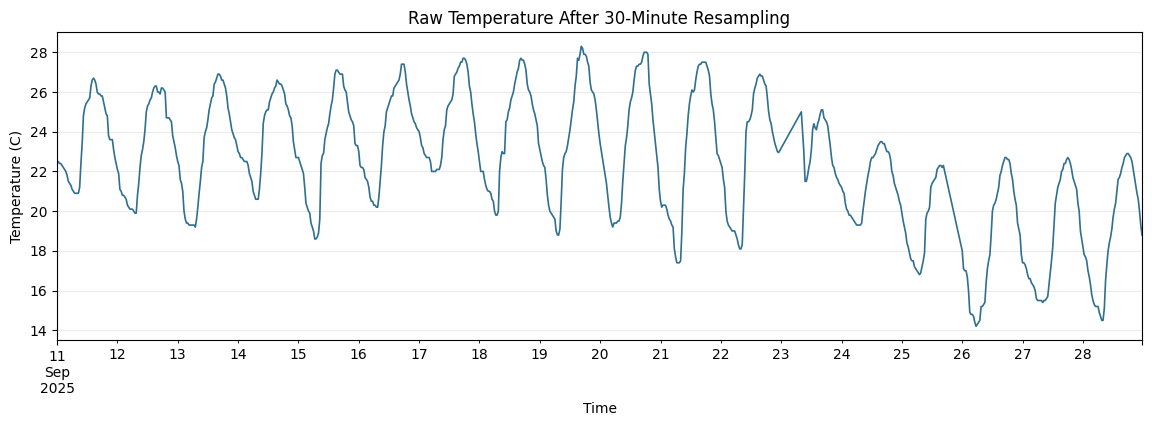

In [3]:
ax = raw_temperature.plot(color="#2f6f8f", linewidth=1.2)
ax.set_title("Raw Temperature After 30-Minute Resampling")
ax.set_ylabel("Temperature (C)")
ax.set_xlabel("Time")
ax.grid(alpha=0.25)
plt.show()

## Baseline

The baseline keeps the original multiplier/consecutive settings but uses positive residual exceedance, matching the high-temperature ramp use case.

In [4]:
baseline_detection = detect_anomalies(
    analysis_temperature,
    threshold_multiplier=3.0,
    consecutive_points_required=MIN_CONSECUTIVE_POINTS,
    direction=DETECTION_DIRECTION,
)
baseline_metrics = compute_metrics(baseline_detection["anomalies"], injected_mask)
print(baseline_metrics)

{'true_positives': 17, 'false_positives': 46, 'false_negatives': 8, 'precision': 0.2698412698412698, 'recall': 0.68, 'f1': 0.3863636363636363, 'total_flags': 63}


## Requested Grid

Requested sweep: `threshold_multiplier in {2.5, 2.0, 1.5}` and `consecutive_points_required in {1, 2}`.

In [5]:
requested_results = run_tuning_grid(
    analysis_temperature,
    injected_mask,
    threshold_multipliers=REQUESTED_THRESHOLD_MULTIPLIERS,
    consecutive_options=TUNING_CONSECUTIVE_OPTIONS,
    direction=DETECTION_DIRECTION,
)

display(requested_results.style.format({
    "precision": "{:.3f}",
    "recall": "{:.3f}",
    "f1": "{:.3f}",
}))

,threshold_multiplier,consecutive_points_required,rolling_window,direction,true_positives,false_positives,false_negatives,precision,recall,f1,total_flags
0,2.500000,1,144,positive,21,57,4,0.269,0.840,0.408,78
1,2.500000,2,144,positive,20,51,5,0.282,0.800,0.417,71
2,2.000000,1,144,positive,22,71,3,0.237,0.880,0.373,93
3,2.000000,2,144,positive,22,65,3,0.253,0.880,0.393,87
4,1.500000,1,144,positive,22,106,3,0.172,0.880,0.288,128
5,1.500000,2,144,positive,22,97,3,0.185,0.880,0.306,119


The requested grid reaches at most 88% recall, so it does not satisfy the ?90% target. I extended the threshold search downward and included a fine threshold near the cutoff.

In [6]:
extended_results = run_tuning_grid(
    analysis_temperature,
    injected_mask,
    threshold_multipliers=EXTENDED_THRESHOLD_MULTIPLIERS,
    consecutive_options=TUNING_CONSECUTIVE_OPTIONS,
    direction=DETECTION_DIRECTION,
)
all_results = pd.concat([requested_results, extended_results], ignore_index=True)
all_results.to_csv(TUNING_RESULTS_PATH, index=False)

best = select_best_parameters(all_results)
print("Best parameters")
print(best.to_string())

display(all_results.style.format({
    "precision": "{:.3f}",
    "recall": "{:.3f}",
    "f1": "{:.3f}",
}))

Best parameters
threshold_multiplier               1.24
consecutive_points_required           2
rolling_window                      144
direction                      positive
true_positives                       23
false_positives                     125
false_negatives                       2
precision                      0.155405
recall                             0.92
f1                             0.265896
total_flags                         148


,threshold_multiplier,consecutive_points_required,rolling_window,direction,true_positives,false_positives,false_negatives,precision,recall,f1,total_flags
0,2.500000,1,144,positive,21,57,4,0.269,0.840,0.408,78
1,2.500000,2,144,positive,20,51,5,0.282,0.800,0.417,71
2,2.000000,1,144,positive,22,71,3,0.237,0.880,0.373,93
3,2.000000,2,144,positive,22,65,3,0.253,0.880,0.393,87
4,1.500000,1,144,positive,22,106,3,0.172,0.880,0.288,128
5,1.500000,2,144,positive,22,97,3,0.185,0.880,0.306,119
6,1.240000,1,144,positive,23,135,2,0.146,0.920,0.251,158
7,1.240000,2,144,positive,23,125,2,0.155,0.920,0.266,148
8,1.230000,1,144,positive,23,137,2,0.144,0.920,0.249,160
9,1.230000,2,144,positive,23,125,2,0.155,0.920,0.266,148


## Tuned Detector Plot

{'true_positives': 23, 'false_positives': 125, 'false_negatives': 2, 'precision': 0.1554054054054054, 'recall': 0.92, 'f1': 0.26589595375722547, 'total_flags': 148}


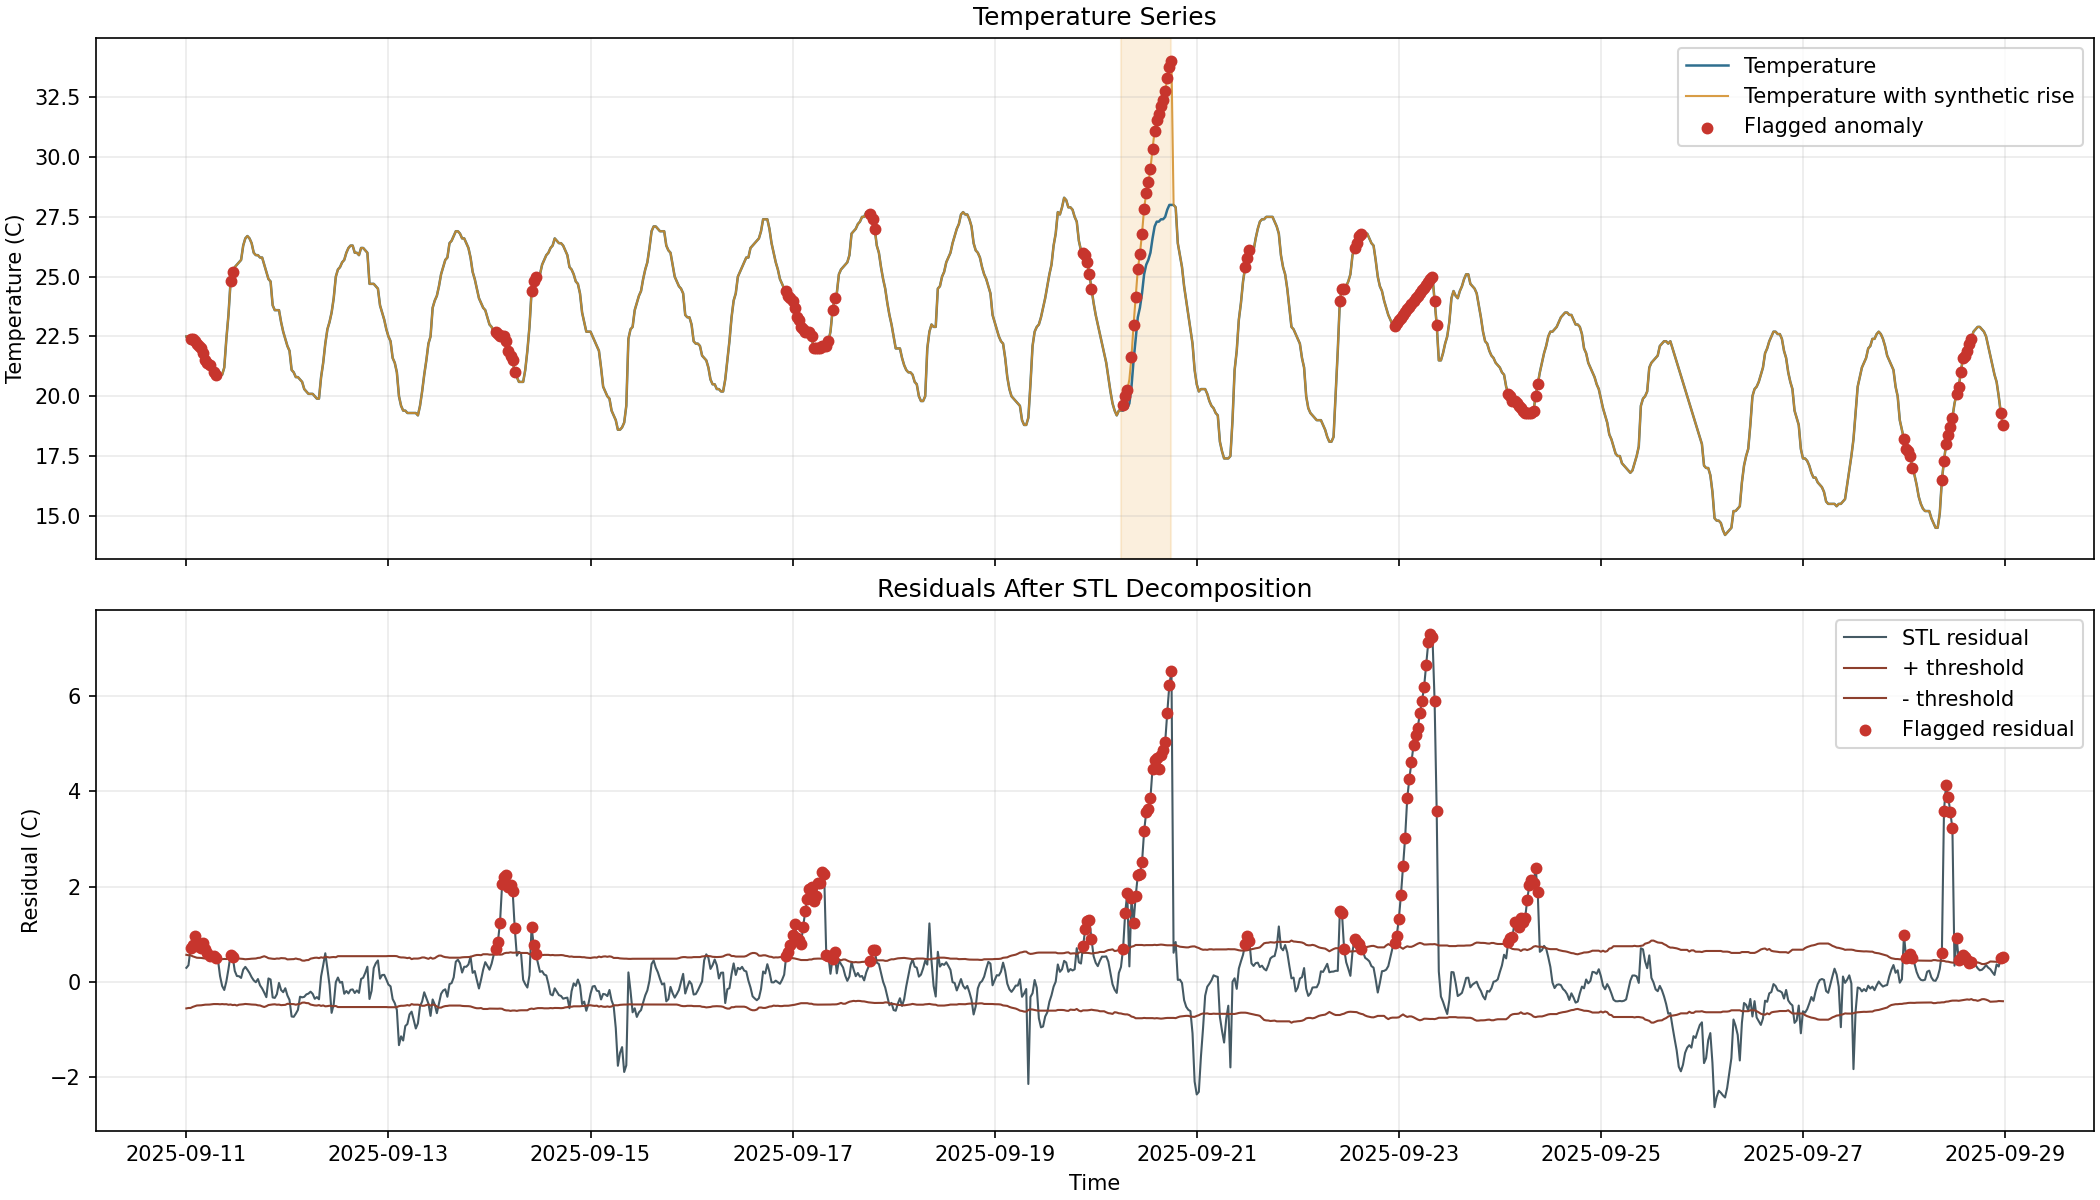

In [7]:
tuned_detection = detect_anomalies(
    analysis_temperature,
    threshold_multiplier=float(best["threshold_multiplier"]),
    consecutive_points_required=int(best["consecutive_points_required"]),
    direction=DETECTION_DIRECTION,
)
tuned_metrics = compute_metrics(tuned_detection["anomalies"], injected_mask)
print(tuned_metrics)

plot_detection(
    raw_temperature=raw_temperature,
    analysis_temperature=analysis_temperature,
    residual=tuned_detection["residual"],
    threshold=tuned_detection["threshold"],
    anomalies=tuned_detection["anomalies"],
    anomaly_window=(ANOMALY_START, anomaly_end),
    output_path=TUNED_PLOT_PATH,
)

display(Image(filename=str(TUNED_PLOT_PATH)))

## False Positive Clustering

Any flagged point outside the injected ramp is counted as a false positive for this offline validation.

In [8]:
false_positives = tuned_detection["anomalies"] & ~injected_mask
run_id = false_positives.ne(false_positives.shift(fill_value=False)).cumsum()
clusters = []
for _, group in false_positives[false_positives].groupby(run_id[false_positives]):
    idx = group.index
    clusters.append({
        "start": idx.min(),
        "end": idx.max(),
        "points": len(idx),
        "max_abs_temp_step_c": float(raw_temperature.diff().abs().reindex(idx).max()),
        "mean_temperature_c": float(raw_temperature.reindex(idx).mean()),
    })

clusters_df = pd.DataFrame(clusters).sort_values(["points", "start"], ascending=[False, True])
print(f"False positive points: {int(false_positives.sum())}")
print(f"False positive clusters: {len(clusters_df)}")
display(clusters_df.head(10))

daily_false_positives = false_positives[false_positives].resample("D").sum().astype(int)
display(daily_false_positives.to_frame("false_positive_points"))

False positive points: 125
False positive clusters: 18


,start,end,points,max_abs_temp_step_c,mean_temperature_c
5,2025-09-16 22:30:00,2025-09-17 08:30:00,21,0.5,22.847619
12,2025-09-22 23:00:00,2025-09-23 09:00:00,21,1.0,23.929762
13,2025-09-24 02:00:00,2025-09-24 09:00:00,15,0.6,19.666667
0,2025-09-11 01:00:00,2025-09-11 05:30:00,10,0.3,21.940000
3,2025-09-14 01:30:00,2025-09-14 06:00:00,10,0.5,22.120000
16,2025-09-28 12:30:00,2025-09-28 16:00:00,8,0.6,21.412500
15,2025-09-28 09:00:00,2025-09-28 11:30:00,6,1.4,18.000000
8,2025-09-19 21:00:00,2025-09-19 23:00:00,5,0.6,25.420000
14,2025-09-28 00:00:00,2025-09-28 02:00:00,5,0.5,17.640000
11,2025-09-22 13:30:00,2025-09-22 15:00:00,4,0.3,26.525000


,false_positive_points
timestamp,
2025-09-11,14
2025-09-12,0
2025-09-13,0
2025-09-14,13
2025-09-15,0
2025-09-16,3
2025-09-17,23
2025-09-18,0
2025-09-19,5
